# LAB 4 - MACHINE_LEARNING GROUP 6
## Hồi Quy Mạng Nơ-ron Nhiều Lớp (MLP): Dự Đoán Giá Nhà
**Bộ dữ liệu:** California Housing (`housing.csv`)

---
## Bước 1: Nhập Các Thư Viện Cần Thiết

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Cố định seed để kết quả tái tạo được
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch version:', torch.__version__)
print('Device:', DEVICE)


---
## Bước 2: Tải và Tiền Xử Lý Dữ Liệu

In [46]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/LAB4/housing.csv')
except:
    df = pd.read_csv('housing.csv')  # chạy local

print('Shape:', df.shape)
df.head()

### 2.1 Thống Kê Mô Tả

In [47]:
# Thống kê mô tả toàn bộ các cột số
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [48]:
# Check data types and missing values
print('=== Data Types ===')
print(df.dtypes)
print()
print('=== Missing Values ===')
print(df.isnull().sum())

=== Data Types ===
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

=== Missing Values ===
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


### 2.2 Trực Quan Hóa Phân Phối Dữ Liệu

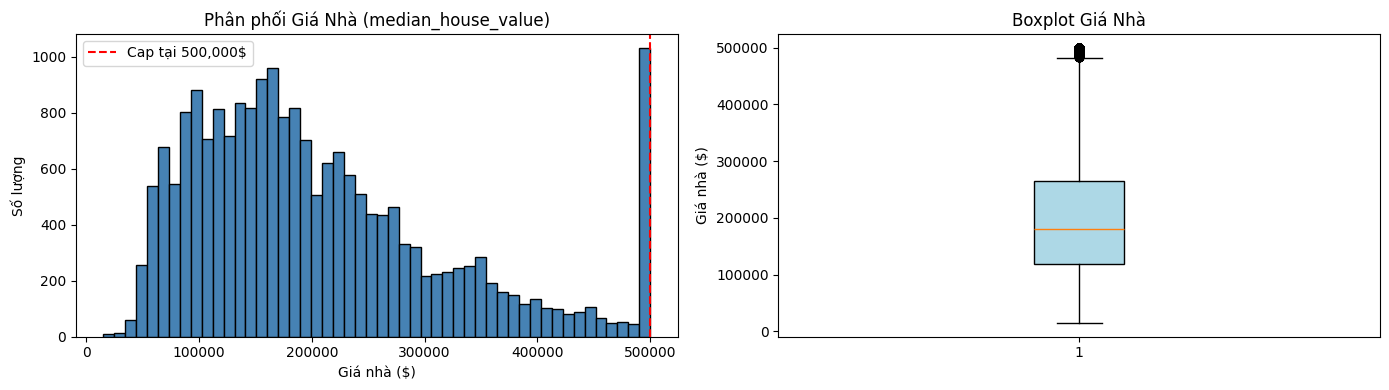

⚠️  Lưu ý: median_house_value bị cắt cụt (cap) tại 500,000$ → có thể gây bias cho mô hình.


In [49]:
# Phân phối của biến mục tiêu (median_house_value)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['median_house_value'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Phân phối Giá Nhà (median_house_value)')
axes[0].set_xlabel('Giá nhà ($)')
axes[0].set_ylabel('Số lượng')
axes[0].axvline(500_000, color='red', linestyle='--', label='Cap tại 500,000$')
axes[0].legend()

# Boxplot để phát hiện outlier
axes[1].boxplot(df['median_house_value'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Boxplot Giá Nhà')
axes[1].set_ylabel('Giá nhà ($)')

plt.tight_layout()
plt.show()
print('⚠️  Lưu ý: median_house_value bị cắt cụt (cap) tại 500,000$ → có thể gây bias cho mô hình.')

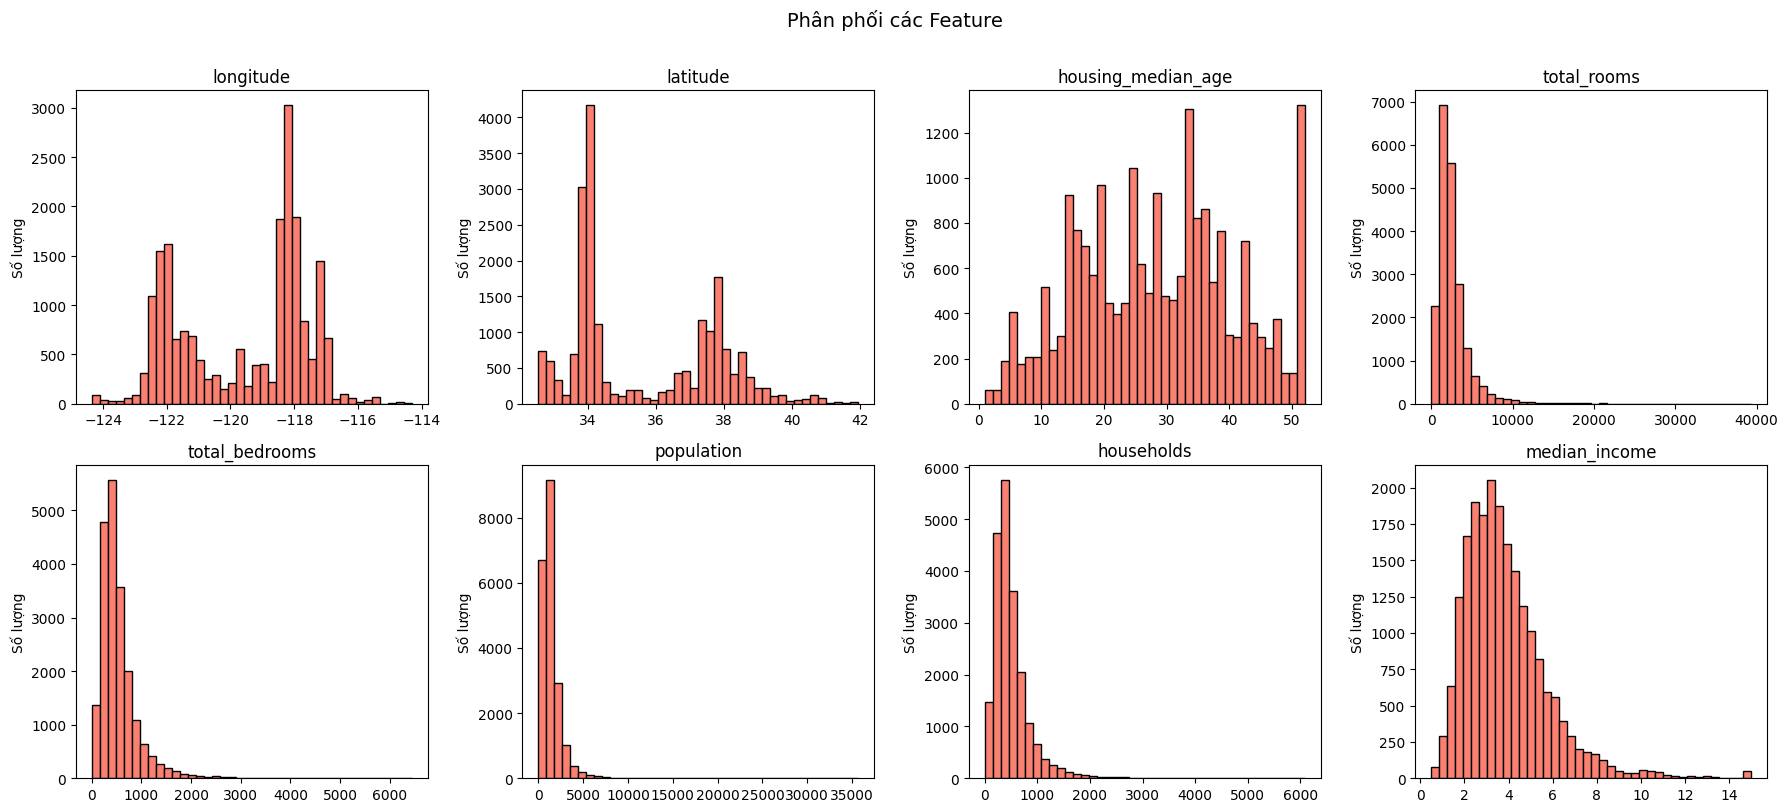

In [50]:
# Histogram của các feature số
num_cols = ['longitude','latitude','housing_median_age','total_rooms',
             'total_bedrooms','population','households','median_income']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), num_cols):
    ax.hist(df[col], bins=40, color='salmon', edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Số lượng')
plt.suptitle('Phân phối các Feature', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

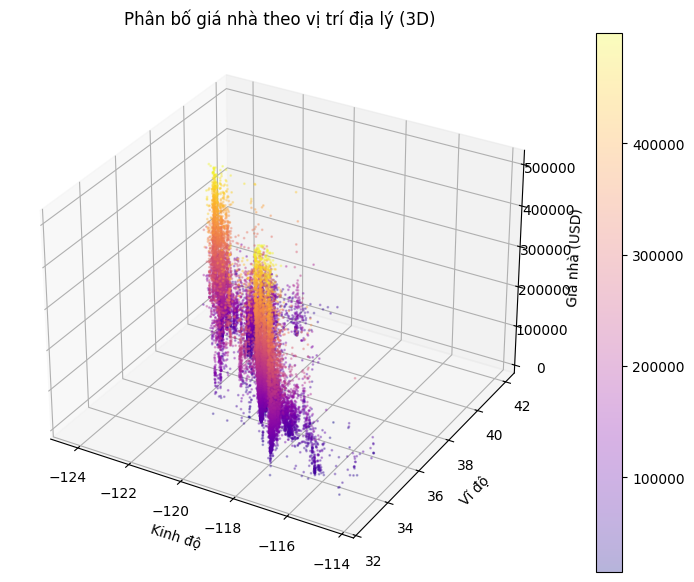

In [62]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    df['longitude'],
    df['latitude'],
    df['median_house_value'],
    c=df['median_house_value'],
    cmap='plasma', alpha=0.3, s=1
)

ax.set_xlabel('Kinh độ')
ax.set_ylabel('Vĩ độ')
ax.set_zlabel('Giá nhà (USD)')
ax.set_title('Phân bố giá nhà theo vị trí địa lý (3D)')
plt.colorbar(sc)
plt.show()

### 2.3 Xử Lý Missing Values & Outlier

In [51]:
# Xử lý Missing Values: điền total_bedrooms bằng median
df = df.fillna({'total_bedrooms': df['total_bedrooms'].median()})

# Loại bỏ các hàng bị cap ở 500,000$ để giảm bias
df = df[df['median_house_value'] < 500000]
print('Shape sau khi loại outlier:', df.shape)

# One-Hot Encode cột phân loại 'ocean_proximity' (nếu chưa xử lý)
if 'ocean_proximity' in df.columns:
    df = pd.get_dummies(df, columns=['ocean_proximity'])
    print('✅ Đã thực hiện One-Hot Encoding.')
else:
    print('ℹ️ Cột ocean_proximity đã được xử lý trước đó.')

print('✅ Hoàn tất xử lý dữ liệu.')
print('Shape cuối cùng:', df.shape)

Shape sau khi loại outlier: (19648, 10)
✅ Đã thực hiện One-Hot Encoding.
✅ Hoàn tất xử lý dữ liệu.
Shape cuối cùng: (19648, 14)


### 2.4 Feature Engineering
Tạo các đặc trưng dẫn xuất có ý nghĩa thực tế từ dữ liệu gốc, giúp mô hình học tốt hơn.

In [52]:
# Tạo feature mới từ tỷ lệ giữa các cột
df['rooms_per_household']      = df['total_rooms']    / df['households']
df['bedrooms_per_room']        = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population']     / df['households']

print('✅ Feature Engineering hoàn tất. Các feature mới:')
print('   • rooms_per_household      = total_rooms / households')
print('   • bedrooms_per_room        = total_bedrooms / total_rooms')
print('   • population_per_household = population / households')
print()
df[['rooms_per_household','bedrooms_per_room','population_per_household']].describe()

✅ Feature Engineering hoàn tất. Các feature mới:
   • rooms_per_household      = total_rooms / households
   • bedrooms_per_room        = total_bedrooms / total_rooms
   • population_per_household = population / households



,rooms_per_household,bedrooms_per_room,population_per_household
count,19648.000000,19648.000000,19648.000000
mean,5.361708,0.215716,3.096560
std,2.293321,0.064626,10.639195
min,0.846154,0.037151,0.692308
25%,4.416667,0.177476,2.446614
50%,5.185730,0.204543,2.837779
75%,5.971083,0.241258,3.306021
max,132.533333,2.824675,1243.333333


In [53]:
# Tách features (X) và target (y) từ dữ liệu đã sạch
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

print('Các features đầu vào:')
print(X.columns.tolist())
print(f'\nTổng số features: {X.shape[1]}')
print(f'Số lượng mẫu sau khi làm sạch: {X.shape[0]}')
print('Target: median_house_value')

Các features đầu vào:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']

Tổng số features: 16
Số lượng mẫu sau khi làm sạch: 19648
Target: median_house_value


### 2.5 Chia dữ liệu và Chuẩn hóa đặc trưng

In [54]:
# Bước 1: Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Bước 2: Chuẩn hóa trên dữ liệu mới
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Training set : {X_train.shape[0]} samples')
print(f'Testing  set : {X_test.shape[0]} samples')
print(f'Num features : {X_train.shape[1]}')

Training set : 15718 samples
Testing  set : 3930 samples
Num features : 16


## Bước 3: Xây dựng mô hình MLP

In [55]:
# Kiến trúc MLP tối ưu với PyTorch: BatchNormalization + Dropout
class MLPRegressor(nn.Module):
    def __init__(self, input_dim):
        super(MLPRegressor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.1),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)   # Linear output cho hồi quy
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


model = MLPRegressor(input_dim=X_train.shape[1]).to(DEVICE)

# Adam với learning rate tùy chỉnh
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTổng số tham số có thể học: {total_params:,}')


## Bước 4: Huấn Luyện Mô Hình

In [57]:
# Chuyển dữ liệu sang Tensor PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=64, shuffle=True
)

# Tham số huấn luyện
EPOCHS        = 300
PATIENCE      = 20   # EarlyStopping
LR_PATIENCE   = 10   # ReduceLROnPlateau
LR_FACTOR     = 0.5
MIN_LR        = 1e-6

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=LR_FACTOR,
    patience=LR_PATIENCE, min_lr=MIN_LR, verbose=True
)

history = {'loss': [], 'val_loss': [], 'mae': [], 'val_mae': []}

best_val_loss   = float('inf')
best_weights    = None
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    # --- Training ---
    model.train()
    train_losses, train_maes = [], []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        train_maes.append(torch.mean(torch.abs(preds - y_batch)).item())

    # --- Validation ---
    model.eval()
    with torch.no_grad():
        val_preds = model(X_test_t.to(DEVICE))
        val_loss  = criterion(val_preds, y_test_t.to(DEVICE)).item()
        val_mae   = torch.mean(torch.abs(val_preds - y_test_t.to(DEVICE))).item()

    epoch_loss = np.mean(train_losses)
    epoch_mae  = np.mean(train_maes)
    history['loss'].append(epoch_loss)
    history['val_loss'].append(val_loss)
    history['mae'].append(epoch_mae)
    history['val_mae'].append(val_mae)

    scheduler.step(val_loss)

    # EarlyStopping + lưu best weights
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_weights     = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\nEarlyStopping tại epoch {epoch}')
            break

    if epoch % 20 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | Loss: {epoch_loss:>12,.2f} | Val Loss: {val_loss:>12,.2f} | MAE: {epoch_mae:>10,.2f} | Val MAE: {val_mae:>10,.2f}')

# Khôi phục trọng số tốt nhất
model.load_state_dict(best_weights)
print(f'\nDừng tại epoch: {len(history["loss"])} | Best Val Loss: {best_val_loss:,.2f}')


### 4.1 Biểu đồ quá trình huấn luyện

In [58]:
# Biểu đồ quá trình huấn luyện: Loss và MAE
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     label='Train Loss (MSE)')
axes[0].plot(history.history['val_loss'], label='Validation Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].set_title('Huấn luyện vs Kiểm định — Loss (MSE)')
axes[0].legend()

axes[1].plot(history.history['mae'],     label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('Huấn luyện vs Kiểm định — MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

## Bước 5: Đánh Giá Mô Hình MLP

In [59]:
# Predict on test set
model.eval()
with torch.no_grad():
    y_pred_mlp = model(X_test_t.to(DEVICE)).cpu().numpy()

mlp_mse  = mean_squared_error(y_test, y_pred_mlp)
mlp_rmse = np.sqrt(mlp_mse)
mlp_r2   = r2_score(y_test, y_pred_mlp)

print(f'[MLP] MSE : {mlp_mse:,.2f}')
print(f'[MLP] RMSE: {mlp_rmse:,.2f}')
print(f'[MLP] R²  : {mlp_r2:.4f}')


In [60]:
# Biểu đồ so sánh giá thực tế và giá dự đoán
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_mlp, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Dự đoán hoàn hảo')
plt.xlabel('Giá thực tế ($)')
plt.ylabel('Giá dự đoán ($)')
plt.title(f'MLP – Giá thực tế vs Giá dự đoán\nRMSE={mlp_rmse:,.0f}  R²={mlp_r2:.3f}')
plt.legend()
plt.tight_layout()
plt.show()